<a href="https://colab.research.google.com/github/Vronska-Anhelina/-Prediction-and-Clustering-Models/blob/main/Customer_Segmentation_with_K_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

purchases = [
    57.0, 49.0, 50.0, 43.0, 47.0, 51.0, 44.0, 52.0, 47.0, 49.0, 47.0, 59.0, 50.0,
    45.0, 54.0, 44.0, 51.0, 40.0, 43.0, 51.0, 74.0, 27.0, 29.0, 31.0, 34.0, 8.0,
    29.0, 56.0, 25.0, 33.0, 35.0, 60.0, 34.0, 31.0, 27.0, 8.0, 13.0, 11.0, 8.0,
    12.0, 10.0, 13.0, 8.0, 9.0, 9.0, 6.0, 11.0, 11.0, 10.0, 9.0
]

spending = [
     524.84, 493.09, 532.38, 576.15, 488.29, 488.29, 578.96, 538.37, 476.53, 527.13,
     476.83, 476.71, 512.1, 404.34, 413.75, 471.89, 449.36, 515.71, 454.6, 429.38,
     329.54, 706.85, 295.37, 287.96, 240.86, 271.21, 281.57, 342.28, 313.74, 229.48,
     312.96, 284.6, 272.92, 324.47, 41.24, 107.23, 130.76, 299.28, 131.29, 47.61,
     116.44, 101.74, 194.02, 101.84, 60.25, 95.61, 107.14, 129.56, 89.63, 83.83
]
data = pd.DataFrame({"purchases":purchases,
                     "spending": spending})
print(data)





    purchases  spending
0        57.0    524.84
1        49.0    493.09
2        50.0    532.38
3        43.0    576.15
4        47.0    488.29
5        51.0    488.29
6        44.0    578.96
7        52.0    538.37
8        47.0    476.53
9        49.0    527.13
10       47.0    476.83
11       59.0    476.71
12       50.0    512.10
13       45.0    404.34
14       54.0    413.75
15       44.0    471.89
16       51.0    449.36
17       40.0    515.71
18       43.0    454.60
19       51.0    429.38
20       74.0    329.54
21       27.0    706.85
22       29.0    295.37
23       31.0    287.96
24       34.0    240.86
25        8.0    271.21
26       29.0    281.57
27       56.0    342.28
28       25.0    313.74
29       33.0    229.48
30       35.0    312.96
31       60.0    284.60
32       34.0    272.92
33       31.0    324.47
34       27.0     41.24
35        8.0    107.23
36       13.0    130.76
37       11.0    299.28
38        8.0    131.29
39       12.0     47.61
40       10.0   

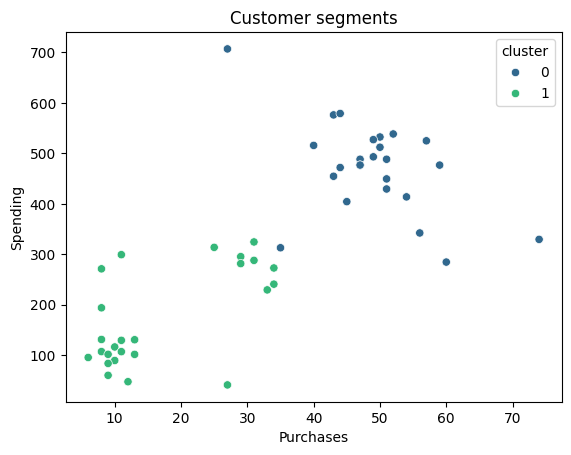

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
data_scaled=scaler.fit_transform(data)
kmeans=KMeans(n_clusters=2,random_state=2026)
data["cluster"]=kmeans.fit_predict(data_scaled)
sns.scatterplot(data=data,
                x="purchases",
                y="spending",
                hue="cluster",
                palette="viridis")
plt.title("Customer segments")
plt.xlabel("Purchases")
plt.ylabel("Spending")
plt.legend(title="cluster")
plt.show()


We see a visual division into two clusters where 0 - customers who bought little and spent little money in the online store. 1 - customers who bought a lot and logically spent a lot of money.

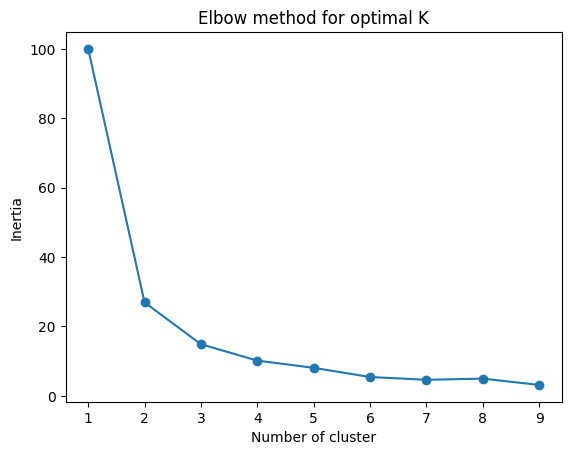

In [ ]:
inertia_values =[]
k_values = range(1,10)
for k in k_values:
  kmeans=KMeans(n_clusters=k,random_state=2026)
  kmeans.fit(data_scaled)
  inertia_values.append(kmeans.inertia_)

plt.plot(k_values, inertia_values,marker="o")
plt.xlabel("Number of cluster")
plt.ylabel("Inertia")
plt.title("Elbow method for optimal K")
plt.show()

We see that the optimal k is either 2 or 3. We will use 3, since 2 is given above.

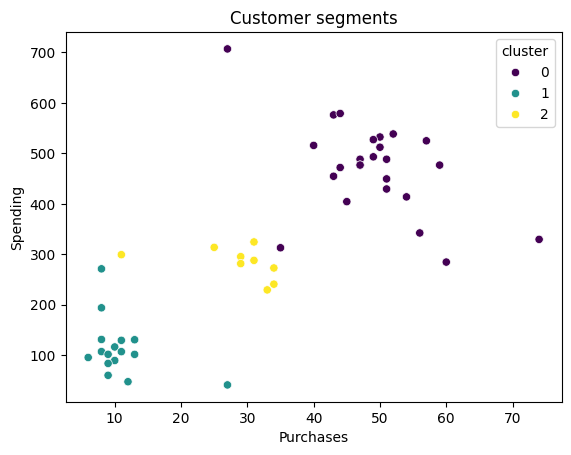

In [ ]:
scaler=StandardScaler()
data_scaled=scaler.fit_transform(data)
kmeans=KMeans(n_clusters=3,random_state=2026)
data["cluster"]=kmeans.fit_predict(data_scaled)
sns.scatterplot(data=data,
                x="purchases",
                y="spending",
                hue="cluster",
                palette="viridis")
plt.title("Customer segments")
plt.xlabel("Purchases")
plt.ylabel("Spending")
plt.legend(title="cluster")
plt.show()


Here we see a slightly different, more logical segmentation. Where 0- customers who bought a lot and spent a lot. 1- the smallest bar, where they spent little and made few purchases, which is logical. And here is added another cluster 2, where customers are in the middle. On average, they spend and make an average number of purchases. This segmentation is more logical than the previous one, due to the addition of cluster 2, which denotes average buyers.